# Filter Process Results Comparison

This notebook compares a previous pipeline run against the new staged pre-LLM filter run.

## What you get
- Run-level totals side by side
- Verdict changes for each name
- Pre-LLM funnel impact from the new run (stage and bucket distributions)
- Optional truth-label accuracy movement (improved, regressed, unchanged)
- Exportable table of changed cases

## Steps
1. Set file paths in the config cell.
2. Run all cells top to bottom.
3. Inspect comparison summaries and changed rows.
4. Export changed rows if needed.

In [1]:
from pathlib import Path
from typing import Optional

import numpy as np
import pandas as pd
from IPython.display import Markdown, display

try:
    import matplotlib.pyplot as plt
    PLOTTING = True
except Exception:
    PLOTTING = False

pd.set_option("display.max_colwidth", 180)
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 220)

## Configuration Notes

- Baseline should point to the old run (before the new filter logic).
- Candidate should point to the new filtered run.
- Labels are optional. If provided, the notebook computes accuracy movement.
- Name matching is exact after trim and lowercase normalization.

In [8]:
# Update these paths before running the rest of the notebook.
BASELINE_RESULTS_PATH = Path("data/score_analysis_results.csv")
CANDIDATE_RESULTS_PATH = Path("data/score_analysis_results_NEW.csv")

LABEL_PATH: Optional[Path] = None
LABEL_SHEET: Optional[str] = None

NAME_COLUMN = "name"
TRUTH_COLUMN: Optional[str] = None

SHOW_TOP_N = 50
EXPORT_CHANGED_PATH = Path("data/filter_comparison_changed.csv")

print(f"BASELINE_RESULTS_PATH = {BASELINE_RESULTS_PATH}")
print(f"CANDIDATE_RESULTS_PATH = {CANDIDATE_RESULTS_PATH}")
print(f"LABEL_PATH            = {LABEL_PATH}")
print(f"EXPORT_CHANGED_PATH   = {EXPORT_CHANGED_PATH}")

BASELINE_RESULTS_PATH = data\score_analysis_results.csv
CANDIDATE_RESULTS_PATH = data\score_analysis_results_NEW.csv
LABEL_PATH            = None
EXPORT_CHANGED_PATH   = data\filter_comparison_changed.csv


In [3]:
def load_table(path: Path, sheet: Optional[str] = None) -> pd.DataFrame:
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(path)
    suffix = path.suffix.lower()
    if suffix == ".csv":
        return pd.read_csv(path)
    if suffix in {".xlsx", ".xls"}:
        data = pd.read_excel(path, sheet_name=sheet)
        if isinstance(data, dict):
            for frame in data.values():
                if isinstance(frame, pd.DataFrame) and not frame.empty:
                    return frame
            return next(iter(data.values()))
        return data
    raise ValueError(f"Unsupported file type: {suffix}")


def normalize_connected(series: pd.Series) -> pd.Series:
    values = series.fillna("").astype(str).str.strip().str.lower()
    mapping = {
        "y": True, "yes": True, "true": True, "1": True, "connected": True,
        "n": False, "no": False, "false": False, "0": False, "not_connected": False,
    }
    return values.map(mapping)


def detect_truth_column(df: pd.DataFrame) -> Optional[str]:
    candidates = [
        TRUTH_COLUMN,
        "actual_connected",
        "ground_truth",
        "truth_connected",
        "is_connected",
        "is_purdue",
        "expected_connected",
        "manual_connected",
        "connected_true",
        "label",
        "truth",
    ]
    for col in candidates:
        if col and col in df.columns:
            return col
    return None


def prepare_results(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    if NAME_COLUMN not in out.columns:
        raise ValueError(f"Missing name column: {NAME_COLUMN}")

    out[NAME_COLUMN] = out[NAME_COLUMN].astype(str).str.strip()
    out["name_key"] = out[NAME_COLUMN].str.lower()

    if "connected" in out.columns:
        out["pred_connected"] = normalize_connected(out["connected"])
    elif "verdict" in out.columns:
        out["pred_connected"] = out["verdict"].astype(str).str.strip().str.lower().eq("connected")
    else:
        out["pred_connected"] = pd.Series([pd.NA] * len(out), dtype="boolean")

    for col in [
        "verdict",
        "confidence",
        "verification_status",
        "relationship_type",
        "summary",
        "primary_source",
        "pre_llm_bucket",
        "pre_llm_stage",
        "pre_llm_score",
        "pre_llm_summary",
        "pre_llm_reason_codes",
        "pre_llm_used_rescue_query",
    ]:
        if col not in out.columns:
            out[col] = pd.NA

    out["pre_llm_score_num"] = pd.to_numeric(out["pre_llm_score"], errors="coerce")
    return out


def merge_truth(cmp_df: pd.DataFrame, labels_df: Optional[pd.DataFrame]) -> pd.DataFrame:
    out = cmp_df.copy()
    if labels_df is None:
        out["truth_connected"] = pd.Series([pd.NA] * len(out), dtype="boolean")
        return out

    labels = labels_df.copy()
    if NAME_COLUMN not in labels.columns:
        raise ValueError(f"Label file missing name column: {NAME_COLUMN}")
    labels[NAME_COLUMN] = labels[NAME_COLUMN].astype(str).str.strip()
    labels["name_key"] = labels[NAME_COLUMN].str.lower()

    truth_col = detect_truth_column(labels)
    if not truth_col:
        raise ValueError("Could not auto-detect truth column in label file. Set TRUTH_COLUMN manually.")

    labels = labels[["name_key", truth_col]].drop_duplicates(subset=["name_key"], keep="first")
    labels["truth_connected"] = normalize_connected(labels[truth_col])
    return out.merge(labels[["name_key", "truth_connected"]], on="name_key", how="left")


def run_summary(df: pd.DataFrame, prefix: str) -> dict:
    return {
        f"{prefix}_rows": int(len(df)),
        f"{prefix}_connected": int(df["pred_connected"].eq(True).sum()),
        f"{prefix}_not_connected": int(df["pred_connected"].eq(False).sum()),
        f"{prefix}_hard_no": int(df.get("pre_llm_bucket", pd.Series(dtype=str)).fillna("").eq("hard_no").sum()),
        f"{prefix}_borderline": int(df.get("pre_llm_bucket", pd.Series(dtype=str)).fillna("").eq("borderline").sum()),
        f"{prefix}_plausible": int(df.get("pre_llm_bucket", pd.Series(dtype=str)).fillna("").eq("plausible").sum()),
    }

In [13]:
baseline_raw = load_table(BASELINE_RESULTS_PATH)
candidate_raw = load_table(CANDIDATE_RESULTS_PATH)
labels_raw = load_table(LABEL_PATH, sheet=LABEL_SHEET) if LABEL_PATH else None

baseline_df = prepare_results(baseline_raw)
candidate_df = prepare_results(candidate_raw)

keep_cols = [
    NAME_COLUMN,
    "name_key",
    "pred_connected",
    "verdict",
    "confidence",
    "verification_status",
    "relationship_type",
    "summary",
    "primary_source",
    "pre_llm_bucket",
    "pre_llm_stage",
    "pre_llm_score",
    "pre_llm_score_num",
    "pre_llm_summary",
    "pre_llm_reason_codes",
    "pre_llm_used_rescue_query",
]

baseline_keep = baseline_df[[c for c in keep_cols if c in baseline_df.columns]].drop_duplicates(subset=["name_key"], keep="first")
candidate_keep = candidate_df[[c for c in keep_cols if c in candidate_df.columns]].drop_duplicates(subset=["name_key"], keep="first")

cmp_df = baseline_keep.merge(
    candidate_keep,
    on="name_key",
    how="outer",
    suffixes=("_base", "_cand"),
)

cmp_df[NAME_COLUMN] = cmp_df.get(f"{NAME_COLUMN}_cand", pd.Series(index=cmp_df.index)).combine_first(
    cmp_df.get(f"{NAME_COLUMN}_base", pd.Series(index=cmp_df.index))
)

cmp_df["in_baseline"] = cmp_df.get(f"{NAME_COLUMN}_base", pd.Series(index=cmp_df.index)).notna()
cmp_df["in_candidate"] = cmp_df.get(f"{NAME_COLUMN}_cand", pd.Series(index=cmp_df.index)).notna()
cmp_df["overlap"] = cmp_df["in_baseline"] & cmp_df["in_candidate"]

cmp_df["verdict_changed"] = cmp_df["pred_connected_base"].astype(str) != cmp_df["pred_connected_cand"].astype(str)
cmp_df.loc[~cmp_df["overlap"], "verdict_changed"] = False

cmp_df["bucket_changed"] = cmp_df["pre_llm_bucket_base"].astype(str) != cmp_df["pre_llm_bucket_cand"].astype(str)
cmp_df.loc[~cmp_df["overlap"], "bucket_changed"] = False

cmp_df["stage_changed"] = cmp_df["pre_llm_stage_base"].astype(str) != cmp_df["pre_llm_stage_cand"].astype(str)
cmp_df.loc[~cmp_df["overlap"], "stage_changed"] = False

cmp_df = merge_truth(cmp_df, labels_raw)

display(Markdown(f"## Rows: baseline={len(baseline_df):,}, candidate={len(candidate_df):,}, merged={len(cmp_df):,}"))
display(cmp_df[[NAME_COLUMN, "in_baseline", "in_candidate", "overlap", "verdict_changed", "bucket_changed", "stage_changed"]].head(20))

## Rows: baseline=607, candidate=607, merged=393

,name,in_baseline,in_candidate,overlap,verdict_changed,bucket_changed,stage_changed
0,A. Dale Kaiser,True,True,True,False,False,False
1,A. Leon Higginbotham,True,True,True,False,False,False
2,A. Stephen Morse,True,True,True,False,False,False
3,Abraham Tesser,True,True,True,False,False,False
4,Akasha Gloria Hull,True,True,True,False,False,False
5,Akira Suzuki,True,True,True,False,False,False
6,Alan Jay Perlis,True,True,True,False,False,False
7,Albert W. Overhauser,True,True,True,False,False,False
8,Albert Warner Overhauser,True,True,True,False,False,False
9,Alexandra Boltasseva,True,True,True,False,False,False


## Run-Level Summary

,value
baseline_rows,607
baseline_connected,0
baseline_not_connected,0
baseline_hard_no,0
baseline_borderline,0
baseline_plausible,0
candidate_rows,607
candidate_connected,0
candidate_not_connected,0
candidate_hard_no,0


## New Filter Funnel (Candidate)

,pre_llm_stage,count
0,(missing),607


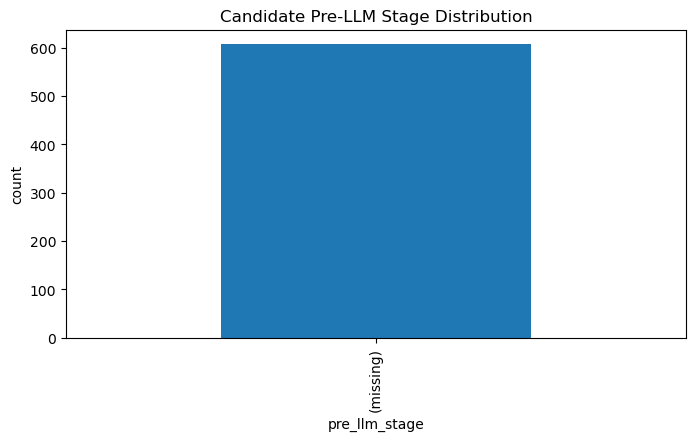

## Verdict Change Breakdown (Overlap Only)

,verdict_changed,bucket_changed,stage_changed,count
0,False,False,False,393


In [14]:
summary = {}
summary.update(run_summary(baseline_df, "baseline"))
summary.update(run_summary(candidate_df, "candidate"))
summary["overlap_rows"] = int(cmp_df["overlap"].sum())
summary["new_only_rows"] = int((~cmp_df["in_baseline"] & cmp_df["in_candidate"]).sum())
summary["dropped_rows"] = int((cmp_df["in_baseline"] & ~cmp_df["in_candidate"]).sum())
summary["verdict_changed_overlap"] = int((cmp_df["overlap"] & cmp_df["verdict_changed"]).sum())

display(Markdown("## Run-Level Summary"))
display(pd.DataFrame([{k: v for k, v in summary.items()}]).T.rename(columns={0: "value"}))

display(Markdown("## New Filter Funnel (Candidate)"))
funnel_df = (
    candidate_df.get("pre_llm_stage", pd.Series(dtype=str))
    .fillna("(missing)")
    .value_counts()
    .rename_axis("pre_llm_stage")
    .reset_index(name="count")
)
display(funnel_df)

if PLOTTING and not funnel_df.empty:
    ax = funnel_df.set_index("pre_llm_stage")["count"].plot(kind="bar", figsize=(8, 4), title="Candidate Pre-LLM Stage Distribution")
    ax.set_xlabel("pre_llm_stage")
    ax.set_ylabel("count")
    plt.show()

display(Markdown("## Verdict Change Breakdown (Overlap Only)"))
change_df = cmp_df[cmp_df["overlap"]].copy()
if change_df.empty:
    print("No overlapping names found between baseline and candidate.")
else:
    display(
        change_df[["verdict_changed", "bucket_changed", "stage_changed"]]
        .value_counts(dropna=False)
        .rename_axis(["verdict_changed", "bucket_changed", "stage_changed"])
        .reset_index(name="count")
    )

In [15]:
display(Markdown("## Changed Cases and Accuracy Movement"))
overlap_df = cmp_df[cmp_df["overlap"]].copy()
changed_df = overlap_df[overlap_df["verdict_changed"] | overlap_df["bucket_changed"] | overlap_df["stage_changed"]].copy()

if changed_df.empty:
    print("No changed rows across overlap.")
else:
    if changed_df["truth_connected"].notna().any():
        base_ok = changed_df["pred_connected_base"] == changed_df["truth_connected"]
        cand_ok = changed_df["pred_connected_cand"] == changed_df["truth_connected"]
        changed_df["accuracy_movement"] = np.select(
            [
                (~base_ok) & (cand_ok),
                (base_ok) & (~cand_ok),
                (base_ok) & (cand_ok),
                (~base_ok) & (~cand_ok),
            ],
            ["improved", "regressed", "stayed_correct", "stayed_wrong"],
            default="unknown",
        )
        display(changed_df["accuracy_movement"].value_counts(dropna=False).rename_axis("accuracy_movement").reset_index(name="count"))
    else:
        changed_df["accuracy_movement"] = "unknown"
        print("No truth labels found. Skipping accuracy movement metrics.")

    show_cols = [
        NAME_COLUMN,
        "pred_connected_base",
        "pred_connected_cand",
        "pre_llm_bucket_base",
        "pre_llm_bucket_cand",
        "pre_llm_stage_base",
        "pre_llm_stage_cand",
        "pre_llm_score_base",
        "pre_llm_score_cand",
        "pre_llm_used_rescue_query_cand",
        "accuracy_movement",
        "summary_base",
        "summary_cand",
    ]
    show_cols = [c for c in show_cols if c in changed_df.columns]
    display(changed_df[show_cols].head(SHOW_TOP_N))

    EXPORT_CHANGED_PATH.parent.mkdir(parents=True, exist_ok=True)
    changed_df[show_cols].to_csv(EXPORT_CHANGED_PATH, index=False)
    print(f"Saved changed rows to {EXPORT_CHANGED_PATH}")

## Changed Cases and Accuracy Movement

No changed rows across overlap.


In [16]:
# Quick validation on a 50-name sample (overlap only)
SAMPLE_N = 50
SAMPLE_SEED = 42

sample_pool = cmp_df[cmp_df["overlap"]].copy()
if sample_pool.empty:
    print("No overlapping names found between baseline and candidate.")
else:
    n = min(SAMPLE_N, len(sample_pool))
    sample_cmp = sample_pool.sample(n=n, random_state=SAMPLE_SEED) if len(sample_pool) > n else sample_pool.copy()

    sample_summary = {
        "sample_size": int(len(sample_cmp)),
        "verdict_changed": int(sample_cmp["verdict_changed"].sum()),
        "bucket_changed": int(sample_cmp["bucket_changed"].sum()),
        "stage_changed": int(sample_cmp["stage_changed"].sum()),
    }

    if "pre_llm_stage_cand" in sample_cmp.columns:
        stage_counts = (
            sample_cmp["pre_llm_stage_cand"]
            .fillna("(missing)")
            .value_counts()
            .rename_axis("pre_llm_stage_cand")
            .reset_index(name="count")
        )
    else:
        stage_counts = pd.DataFrame(columns=["pre_llm_stage_cand", "count"])

    display(Markdown(f"## 50-Name Sample Test (n={len(sample_cmp)})"))
    display(pd.DataFrame([sample_summary]))
    if not stage_counts.empty:
        display(Markdown("### Candidate Stage Distribution (Sample)"))
        display(stage_counts)

    sample_cols = [
        NAME_COLUMN,
        "pred_connected_base",
        "pred_connected_cand",
        "pre_llm_bucket_base",
        "pre_llm_bucket_cand",
        "pre_llm_stage_cand",
        "verdict_changed",
        "bucket_changed",
        "stage_changed",
    ]
    sample_cols = [c for c in sample_cols if c in sample_cmp.columns]
    display(Markdown("### Sample Rows"))
    display(sample_cmp[sample_cols].sort_values(["verdict_changed", "bucket_changed", "stage_changed", NAME_COLUMN], ascending=[False, False, False, True]).head(50))

## 50-Name Sample Test (n=50)

,sample_size,verdict_changed,bucket_changed,stage_changed
0,50,0,0,0


### Candidate Stage Distribution (Sample)

,pre_llm_stage_cand,count
0,(missing),50


### Sample Rows

,name,pred_connected_base,pred_connected_cand,pre_llm_bucket_base,pre_llm_bucket_cand,pre_llm_stage_cand,verdict_changed,bucket_changed,stage_changed
0,A. Dale Kaiser,<NA>,<NA>,<NA>,<NA>,<NA>,False,False,False
9,Alexandra Boltasseva,<NA>,<NA>,<NA>,<NA>,<NA>,False,False,False
15,Alvin Carl Plantinga,<NA>,<NA>,<NA>,<NA>,<NA>,False,False,False
25,"Arden L. Bement, Jr.",<NA>,<NA>,<NA>,<NA>,<NA>,False,False,False
33,Ben R. Mottelson,<NA>,<NA>,<NA>,<NA>,<NA>,False,False,False
42,C. N. R. Rao,<NA>,<NA>,<NA>,<NA>,<NA>,False,False,False
46,Cecil Edmund Yarwood,<NA>,<NA>,<NA>,<NA>,<NA>,False,False,False
55,Christopher N. Bowman,<NA>,<NA>,<NA>,<NA>,<NA>,False,False,False
57,Clark Spencer Larsen,<NA>,<NA>,<NA>,<NA>,<NA>,False,False,False
72,Donald Knight Wilgus,<NA>,<NA>,<NA>,<NA>,<NA>,False,False,False
